In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv("../Data/healthcare_patient_cleaned.csv")


In [3]:
total_patients = df['patient_nbr'].nunique()

print("Total Patients:", total_patients)


Total Patients: 71518


In [4]:
total_encounters = df['encounter_id'].nunique()

print("Total Encounters:", total_encounters)


Total Encounters: 101766


In [5]:
avg_stay = df['time_in_hospital'].mean()

print("Average Hospital Stay:", round(avg_stay, 2))


Average Hospital Stay: 4.4


In [6]:
readmission_rate = df['readmission_flag'].mean() * 100

print("Readmission Rate:", round(readmission_rate, 2), "%")


Readmission Rate: 46.09 %


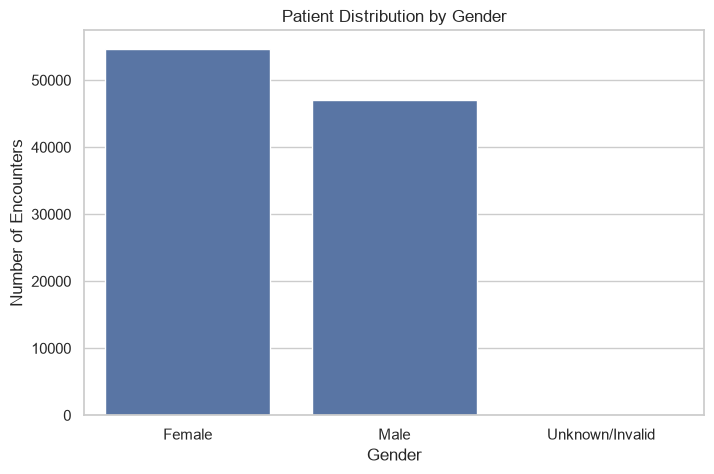

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='gender'
)

plt.title('Patient Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Encounters')

plt.show()


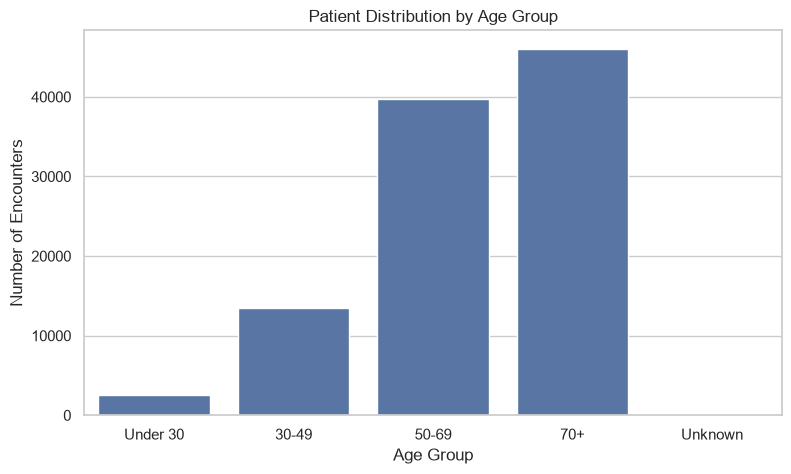

In [9]:
plt.figure(figsize=(9,5))

order = [
    'Under 30',
    '30-49',
    '50-69',
    '70+',
    'Unknown'
]

sns.countplot(
    data=df,
    x='age_group',
    order=order
)

plt.title('Patient Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Encounters')

plt.show()


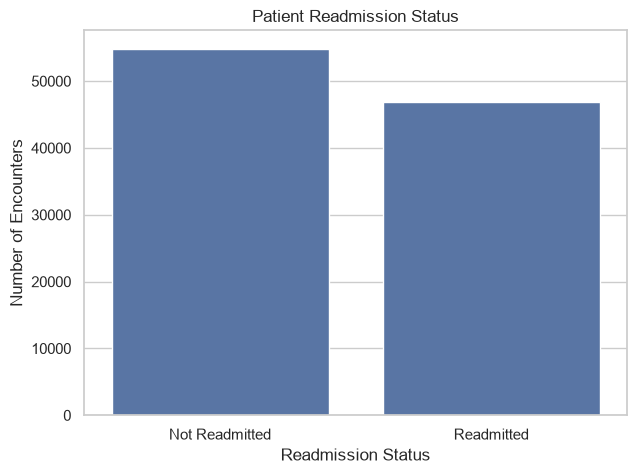

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='readmission_status'
)

plt.title('Patient Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Encounters')

plt.show()


In [11]:
readmission_by_age = (
    df.groupby('age_group')['readmission_flag']
    .mean()
    .mul(100)
    .reset_index()
)


In [12]:
readmission_by_age


,age_group,readmission_flag
0,30-49,43.952452
1,50-69,45.255291
2,70+,47.685527
3,Under 30,41.410921


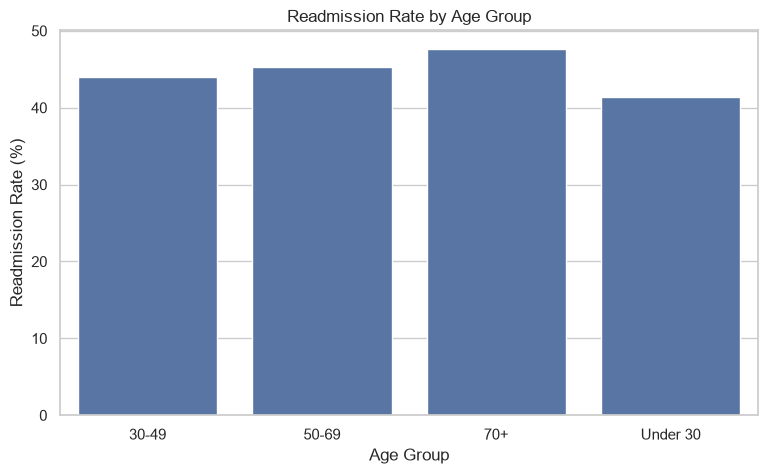

In [13]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=readmission_by_age,
    x='age_group',
    y='readmission_flag'
)

plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')

plt.show()


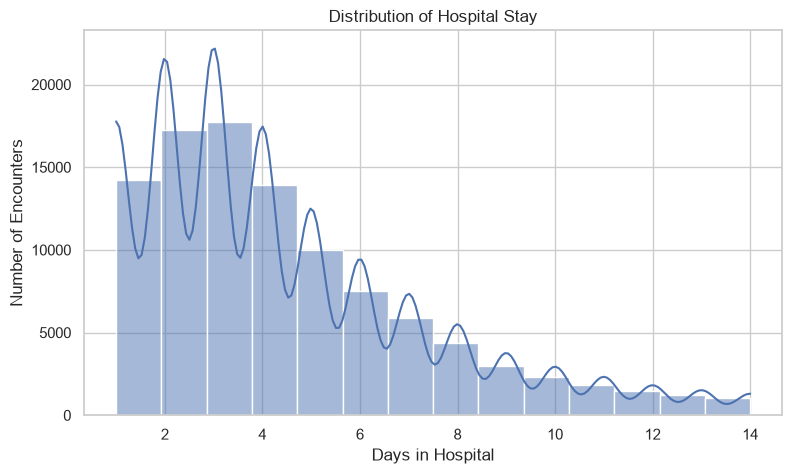

In [14]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x='time_in_hospital',
    bins=14,
    kde=True
)

plt.title('Distribution of Hospital Stay')
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Encounters')

plt.show()


In [15]:
stay_readmission = (
    df.groupby('stay_category')['readmission_flag']
    .mean()
    .mul(100)
    .reset_index()
)

stay_readmission


,stay_category,readmission_flag
0,Long Stay,49.620667
1,Medium Stay,48.465994
2,Short Stay,43.187363


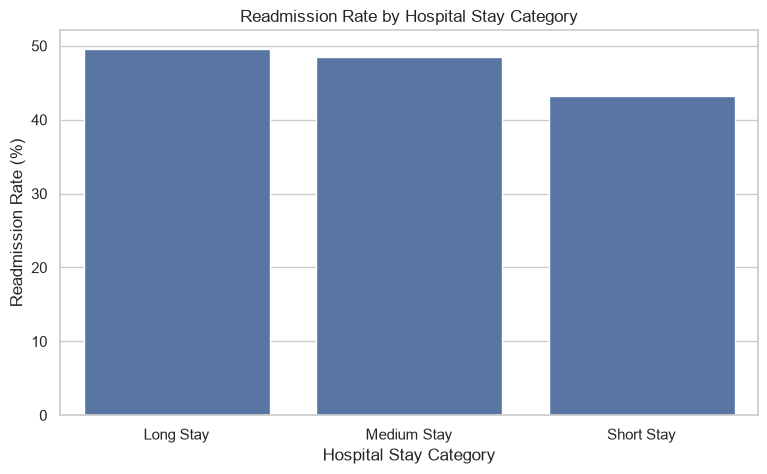

In [16]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=stay_readmission,
    x='stay_category',
    y='readmission_flag'
)

plt.title('Readmission Rate by Hospital Stay Category')
plt.xlabel('Hospital Stay Category')
plt.ylabel('Readmission Rate (%)')

plt.show()


In [17]:
prior_visit_readmission = (
    df.groupby('prior_visit_category')['readmission_flag']
    .mean()
    .mul(100)
    .reset_index()
)

prior_visit_readmission


,prior_visit_category,readmission_flag
0,1-2 Visits,53.131354
1,3-5 Visits,64.022589
2,6+ Visits,76.587571
3,No Prior Visits,36.187934


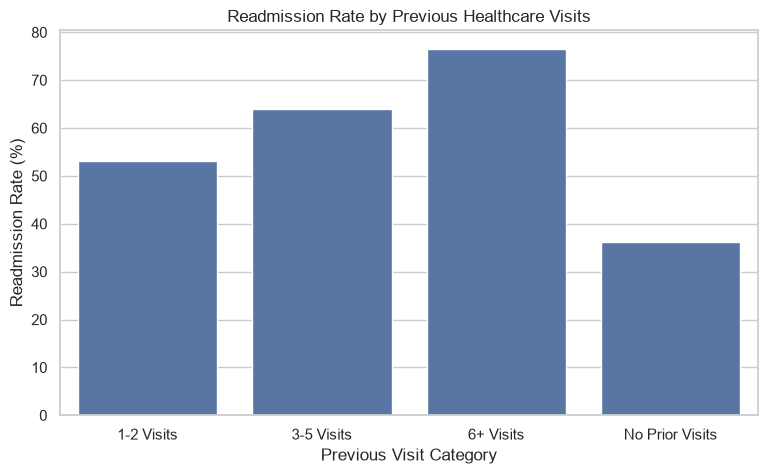

In [18]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=prior_visit_readmission,
    x='prior_visit_category',
    y='readmission_flag'
)

plt.title('Readmission Rate by Previous Healthcare Visits')
plt.xlabel('Previous Visit Category')
plt.ylabel('Readmission Rate (%)')

plt.show()


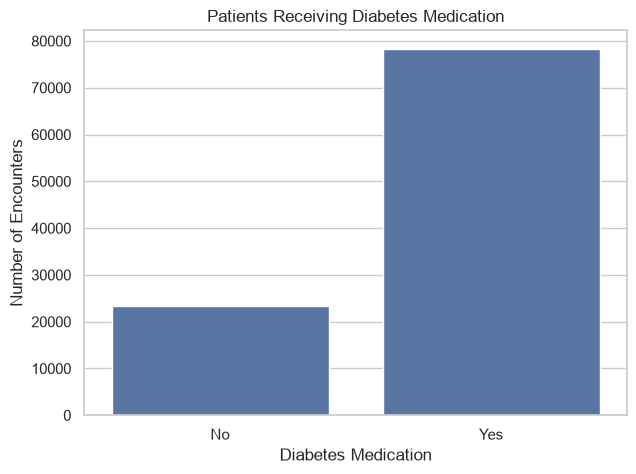

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='diabetesMed'
)

plt.title('Patients Receiving Diabetes Medication')
plt.xlabel('Diabetes Medication')
plt.ylabel('Number of Encounters')

plt.show()


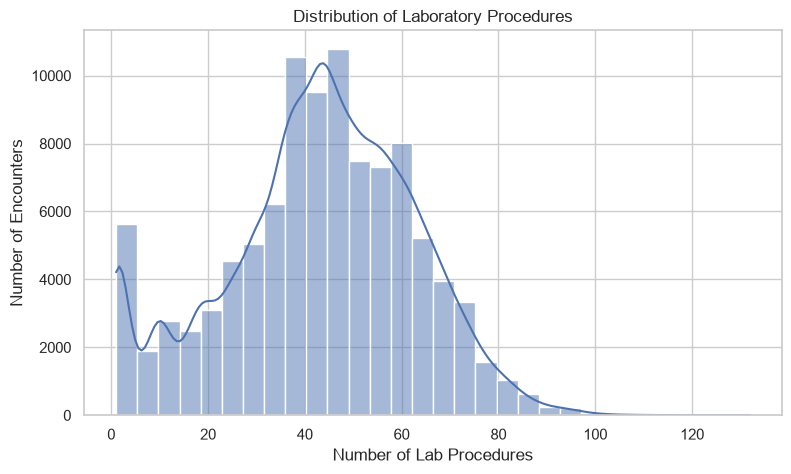

In [20]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x='num_lab_procedures',
    bins=30,
    kde=True
)

plt.title('Distribution of Laboratory Procedures')
plt.xlabel('Number of Lab Procedures')
plt.ylabel('Number of Encounters')

plt.show()


In [21]:
numeric_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'readmission_flag'
]


In [22]:
corr = df[numeric_cols].corr()


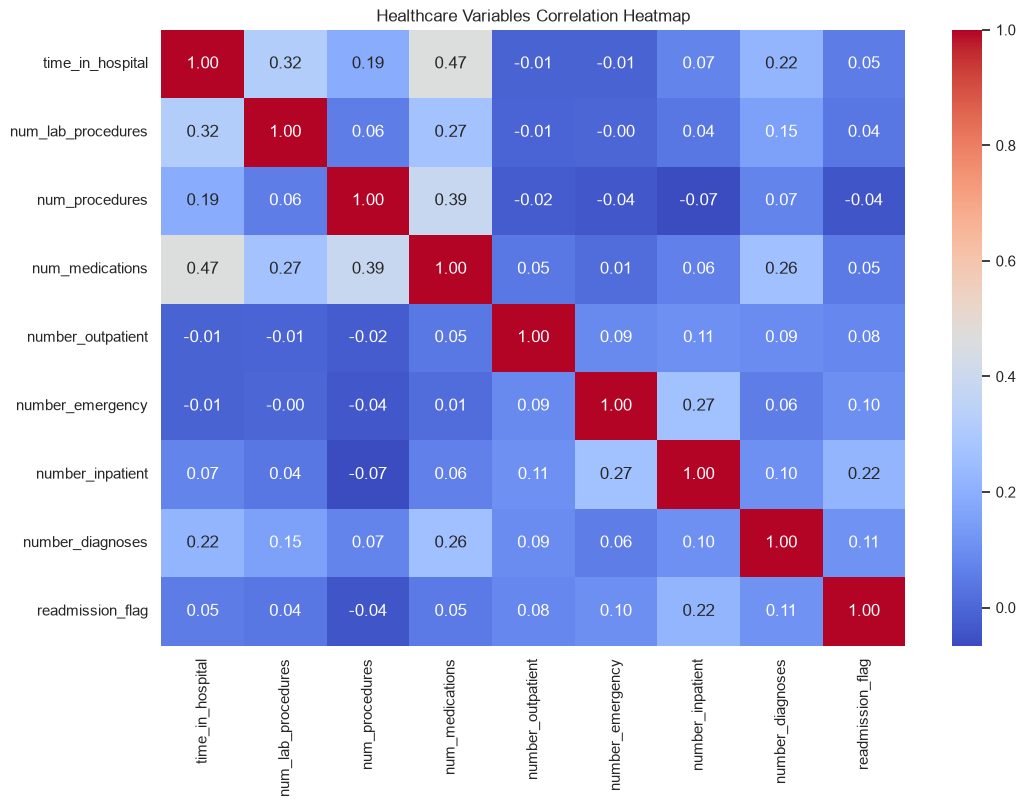

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Healthcare Variables Correlation Heatmap')

plt.show()


In [24]:
insights = pd.DataFrame({
    'Metric': [
        'Total Patients',
        'Total Encounters',
        'Average Hospital Stay',
        'Readmission Rate'
    ],
    'Value': [
        total_patients,
        total_encounters,
        round(avg_stay, 2),
        round(readmission_rate, 2)
    ]
})

insights


,Metric,Value
0,Total Patients,71518.00
1,Total Encounters,101766.00
2,Average Hospital Stay,4.40
3,Readmission Rate,46.09


In [25]:
insights.to_csv(
    "../reports/key_metrics.csv",
    index=False
)


In [27]:
total_patients = df["patient_nbr"].nunique()
total_encounters = df["encounter_id"].nunique()
average_stay = df["time_in_hospital"].mean()
readmission_rate = df["readmission_flag"].mean() * 100

print("Total Patients:", total_patients)
print("Total Encounters:", total_encounters)
print("Average Hospital Stay:", round(average_stay, 2))
print("Readmission Rate:", round(readmission_rate, 2), "%")


Total Patients: 71518
Total Encounters: 101766
Average Hospital Stay: 4.4
Readmission Rate: 46.09 %


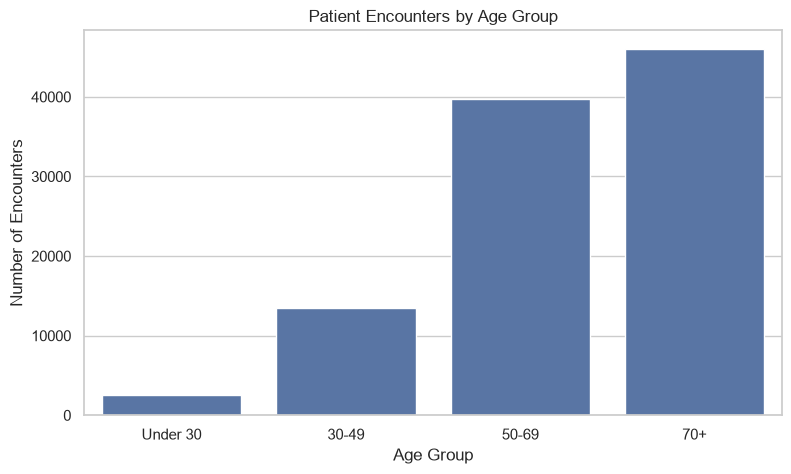

In [28]:
plt.figure(figsize=(9,5))

order = ["Under 30", "30-49", "50-69", "70+"]

sns.countplot(
    data=df,
    x="age_group",
    order=order
)

plt.title("Patient Encounters by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")

plt.show()


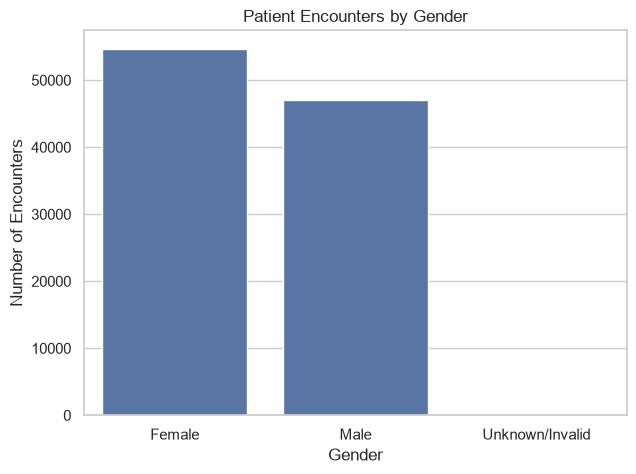

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Patient Encounters by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Encounters")

plt.show()


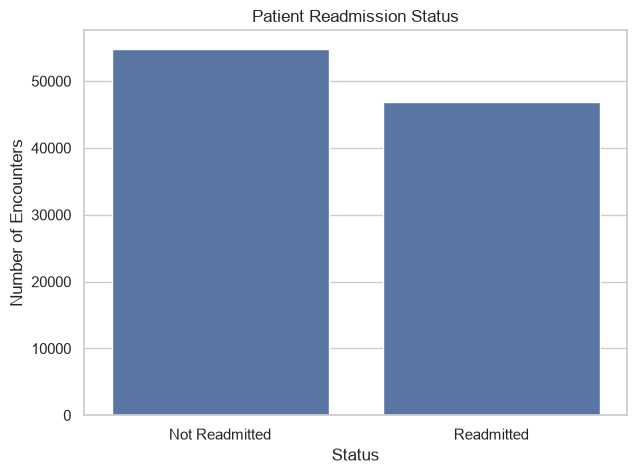

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="readmission_status"
)

plt.title("Patient Readmission Status")
plt.xlabel("Status")
plt.ylabel("Number of Encounters")

plt.show()


In [31]:
age_readmission = (
    df.groupby("age_group")["readmission_flag"]
    .mean()
    .mul(100)
    .reset_index()
)

age_readmission


,age_group,readmission_flag
0,30-49,43.952452
1,50-69,45.255291
2,70+,47.685527
3,Under 30,41.410921


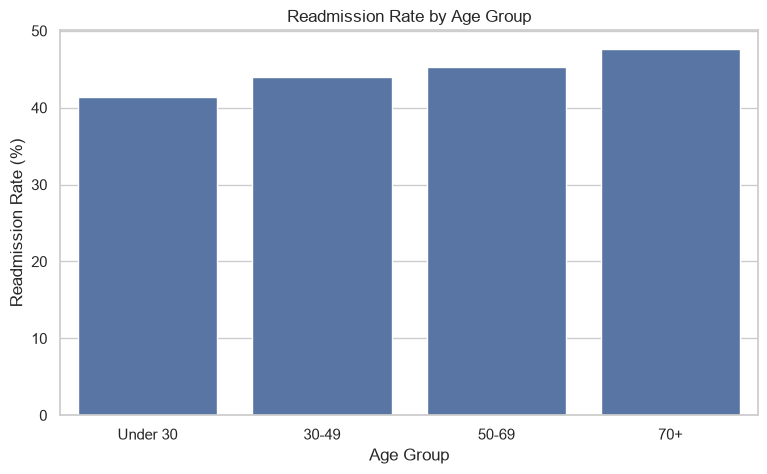

In [32]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=age_readmission,
    x="age_group",
    y="readmission_flag",
    order=["Under 30", "30-49", "50-69", "70+"]
)

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")

plt.show()


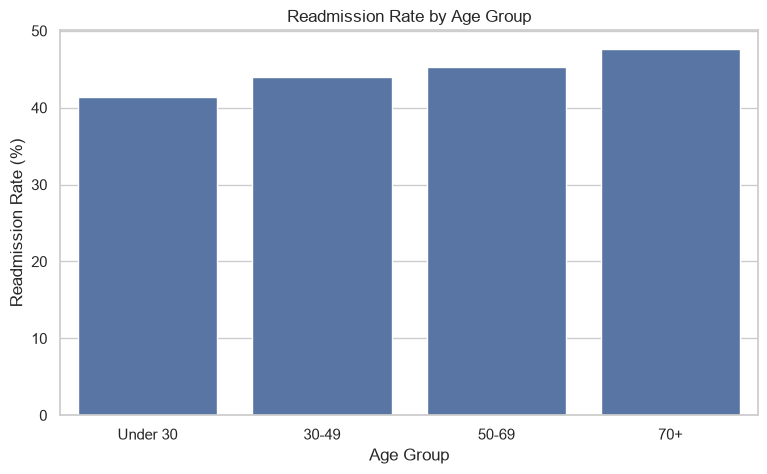

In [33]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=age_readmission,
    x="age_group",
    y="readmission_flag",
    order=["Under 30", "30-49", "50-69", "70+"]
)

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")

plt.show()


In [34]:
prior_visit_analysis = (
    df.groupby("prior_visit_category")["readmission_flag"]
    .mean()
    .mul(100)
    .reset_index()
)

prior_visit_analysis


,prior_visit_category,readmission_flag
0,1-2 Visits,53.131354
1,3-5 Visits,64.022589
2,6+ Visits,76.587571
3,No Prior Visits,36.187934


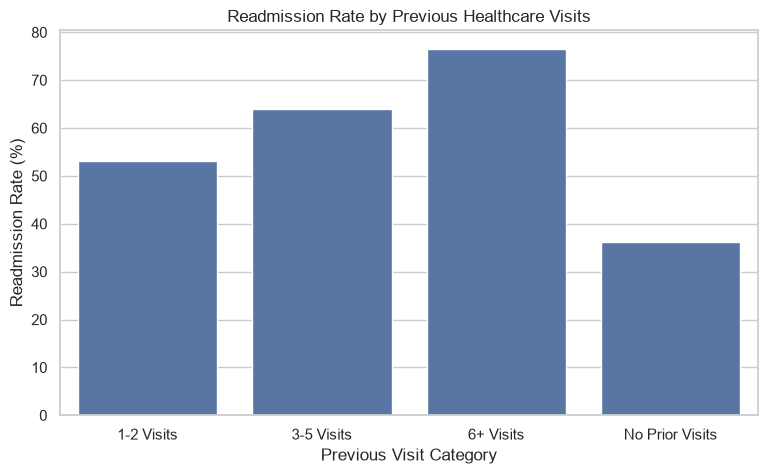

In [35]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=prior_visit_analysis,
    x="prior_visit_category",
    y="readmission_flag"
)

plt.title("Readmission Rate by Previous Healthcare Visits")
plt.xlabel("Previous Visit Category")
plt.ylabel("Readmission Rate (%)")

plt.show()


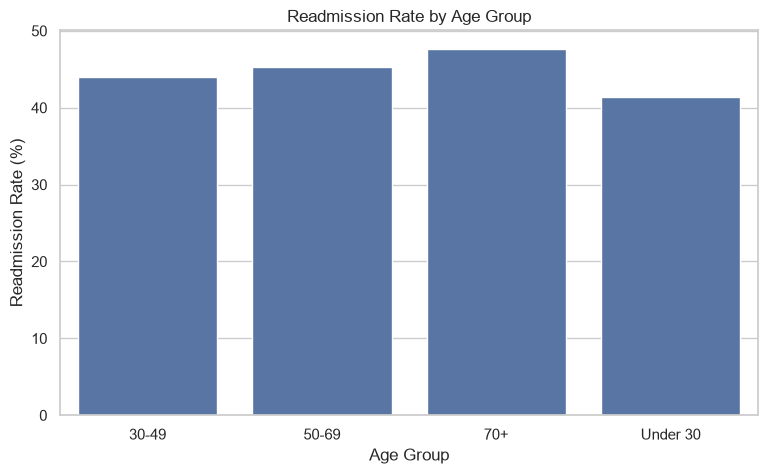

In [37]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=age_readmission,
    x="age_group",
    y="readmission_flag"
)

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")

plt.savefig(
    "../images/readmission_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


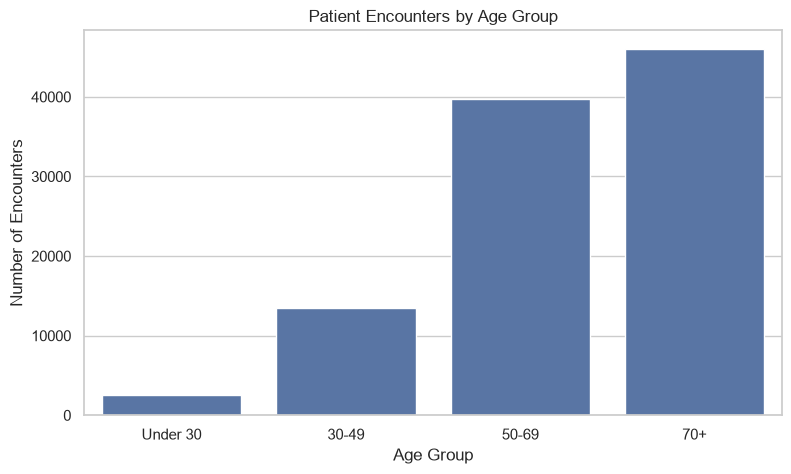

In [38]:
plt.figure(figsize=(9,5))

order = ["Under 30", "30-49", "50-69", "70+"]

sns.countplot(
    data=df,
    x="age_group",
    order=order
)

plt.title("Patient Encounters by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")

plt.savefig(
    "../images/01_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


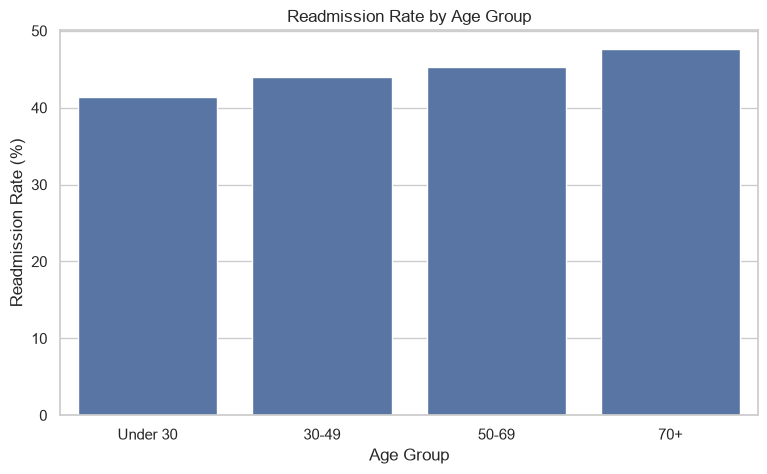

In [39]:
age_readmission = (
    df.groupby("age_group")["readmission_flag"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(9,5))

order = ["Under 30", "30-49", "50-69", "70+"]

sns.barplot(
    data=age_readmission,
    x="age_group",
    y="readmission_flag",
    order=order
)

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")

plt.savefig(
    "../images/04_readmission_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [40]:
import os

README_FILE = "README.md"
IMAGE_FOLDER = "images"

# Image extensions to include
extensions = (".png", ".jpg", ".jpeg", ".webp")

# Get all images
images = [
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith(extensions)
]

# Sort them
images.sort()

# Create README section
section = "\n## 📊 Project Visualizations\n\n"

for i, image in enumerate(images, start=1):
    title = os.path.splitext(image)[0].replace("_", " ").title()

    section += f"### {i}. {title}\n\n"
    section += f"![{title}]({IMAGE_FOLDER}/{image})\n\n"

# Read README
with open(README_FILE, "r", encoding="utf-8") as f:
    content = f.read()

# Add section at the end
with open(README_FILE, "w", encoding="utf-8") as f:
    f.write(content.rstrip() + "\n" + section)

print("✅ Images added to README.md")

FileNotFoundError: [Errno 2] No such file or directory: 'images'